# Práctica 2 - Computer Vision


In [63]:
import os
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, ParameterGrid
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
)
import xgboost as xgb

## Descargar Dataset


In [23]:
import kagglehub

path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/emmarex/plantdisease


## Funciones Auxiliares


In [37]:
def read_image_rgb(path, resize=None):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    if resize is not None:
        img = cv2.resize(img, resize)
    return img


def show_images(images, titles=None, cols=4, figsize=(14, 8), cmap=None):
    n = len(images)
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap if cmap else "gray")
        else:
            plt.imshow(img)
        if titles is not None:
            plt.title(str(titles[i]))
        plt.axis("off")
    plt.tight_layout()
    plt.show()


def overlay_points(image_rgb, points, color=(255, 0, 0), radius=2):
    img = image_rgb.copy()
    for y, x in points:
        cv2.circle(img, (int(x), int(y)), radius, color, -1)
    return img


def build_dataframe_from_folder(dataset_dir):
    valid_ext = {".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"}
    
    rows = []
    
    class_dirs = sorted(
        [
            d for d in os.listdir(dataset_dir)
            if os.path.isdir(os.path.join(dataset_dir, d))
        ]
    )
    
    for class_name in class_dirs:
        class_path = os.path.join(dataset_dir, class_name)
        
        for fname in os.listdir(class_path):
            ext = os.path.splitext(fname)[1]
            
            if ext in valid_ext:
                rows.append(
                    {"path": os.path.join(class_path, fname), "label": class_name}
                )
                
    return pd.DataFrame(rows)


## Carga del Dataset


In [38]:
DATASET_PATH = path + '/PlantVillage'

df_images = build_dataframe_from_folder(DATASET_PATH)

print("Cantidad total de imágenes:", len(df_images))
print("Cantidad de clases:", df_images["label"].nunique())

display(df_images.head())
display(df_images["label"].value_counts().sort_index())

Cantidad total de imágenes: 20638
Cantidad de clases: 15


,path,label
0,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Pepper__bell___Bacterial_spot
1,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Pepper__bell___Bacterial_spot
2,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Pepper__bell___Bacterial_spot
3,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Pepper__bell___Bacterial_spot
4,/kaggle/input/datasets/emmarex/plantdisease/Pl...,Pepper__bell___Bacterial_spot


label
Pepper__bell___Bacterial_spot                   997
Pepper__bell___healthy                         1478
Potato___Early_blight                          1000
Potato___Late_blight                           1000
Potato___healthy                                152
Tomato_Bacterial_spot                          2127
Tomato_Early_blight                            1000
Tomato_Late_blight                             1909
Tomato_Leaf_Mold                                952
Tomato_Septoria_leaf_spot                      1771
Tomato_Spider_mites_Two_spotted_spider_mite    1676
Tomato__Target_Spot                            1404
Tomato__Tomato_YellowLeaf__Curl_Virus          3208
Tomato__Tomato_mosaic_virus                     373
Tomato_healthy                                 1591
Name: count, dtype: int64

## Muestra del Dataset


(300, 2)

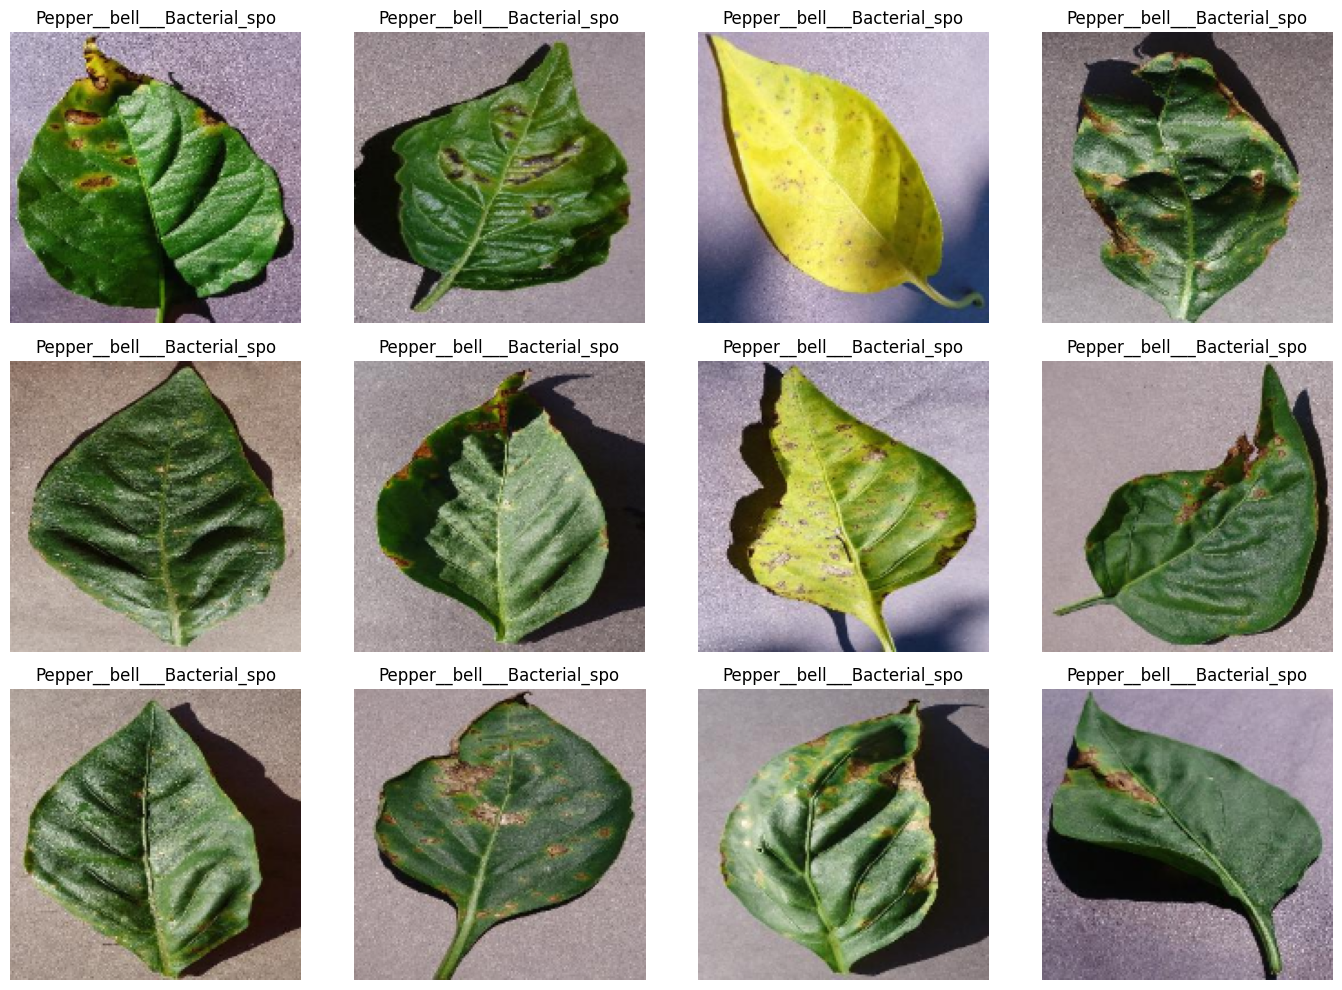

In [60]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sample_parts = []

for label_name, group in df_images.groupby("label"):
    n_take = 20
    sample_parts.append(group.sample(n=n_take, random_state=RANDOM_STATE))

# Posee 20 imagenes por cada clase
sample_df = pd.concat(sample_parts, axis=0).reset_index(drop=True)
display(sample_df.shape)

imgs = [read_image_rgb(p, resize=(160, 160)) for p in sample_df["path"][:12]]
titles = [str(lbl)[:28] for lbl in sample_df["label"][:12]]
show_images(imgs, titles=titles, cols=4, figsize=(14, 10))

## Entrenamiento de clasificador

### Placeholder

In [62]:
def extract_dummy_features(image_rgb, output_size=(16, 16)):
    """
    Descriptor de mentira: simplemente redimensiona la imagen a 16x16
    y la aplana en un vector 1D de 16x16x3 = 768 características.
    Solo para que el clasificador tenga números con los que jugar.
    """
    img_res = cv2.resize(image_rgb, output_size)
    return img_res.flatten().astype(np.float32)


print("Extrayendo características DUMMY para probar clasificadores...")

# Usamos solo una pequeña muestra del dataset para que corra muy rápido en pruebas (N=300 en total)
sample_test_df = sample_df.copy()

dummy_features = []
labels = []

for _, row in sample_test_df.iterrows():
    path = row["path"]
    label_name = row["label"]

    image_rgb = read_image_rgb(path)
    # Aquí irían las funciones de tu equipo, por ahora usamos el dummy
    vec = extract_dummy_features(image_rgb)

    dummy_features.append(vec)
    labels.append(label_name)

X_dummy = np.array(dummy_features)
y_labels_dummy = np.array(labels)

print(f"\nMatriz X (Features) lista: Forma {X_dummy.shape}")
print(f"Vector Y (Labels) listo: Forma {y_labels_dummy.shape}")

Extrayendo características DUMMY para probar clasificadores...

Matriz X (Features) lista: Forma (300, 768)
Vector Y (Labels) listo: Forma (300,)


### Módulo de Evaluación

In [65]:
def base_evaluator(X, y_labels, modelo_base, parametros, nombre_modelo, k=5):
    """
    Función oculta que hace el trabajo pesado de Cross Validation
    para no repetir el código (Normalización, Búsqueda de Hyperparams, etc.)
    """
    le = LabelEncoder()
    y = le.fit_transform(y_labels)
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    print(f"\n--- Inicializando k-fold (k={k}) para {nombre_modelo} ---")

    y_true_totales, y_pred_totales = [], []
    fold_accs, fold_f1s = [], []

    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        # Normalizar
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        mejor_score = -1
        mejor_modelo_fold = None

        # Búsqueda manual de hiperparámetros (Grid Search)
        for config in ParameterGrid(parametros):
            modelo_tmp = modelo_base.set_params(**config)
            modelo_tmp.fit(X_train_scaled, y_train)
            val_preds = modelo_tmp.predict(X_val_scaled)
            f1_val = f1_score(y_val, val_preds, average="macro", zero_division=0)

            if f1_val > mejor_score:
                mejor_score = f1_val
                mejor_modelo_fold = modelo_tmp

        # Predicción Final de este fold
        mejores_preds = mejor_modelo_fold.predict(X_val_scaled)
        fold_accs.append(accuracy_score(y_val, mejores_preds))
        fold_f1s.append(
            f1_score(y_val, mejores_preds, average="macro", zero_division=0)
        )

        y_true_totales.extend(y_val)
        y_pred_totales.extend(mejores_preds)

    # Calcular promedios
    mean_acc = np.mean(fold_accs)
    mean_f1 = np.mean(fold_f1s)
    cm = confusion_matrix(y_true_totales, y_pred_totales)
    reporte = classification_report(
        y_true_totales, y_pred_totales, target_names=le.classes_, zero_division=0
    )

    print(
        f"Resultados {nombre_modelo}: Accuracy_CV={mean_acc:.3f} | F1_Macro_CV={mean_f1:.3f}"
    )

    return {
        "modelo": nombre_modelo,
        "accuracy_medio": mean_acc,
        "f1_score_medio": mean_f1,
        "matriz_confusion": cm,
        "reporte_clases": reporte,
        "etiquetas_raw": le.classes_,
    }


# ----- TUS 3 FUNCIONES PÚBLICAS INDEPENDIENTES -----


def evaluar_knn(X, y_labels, k_fold=5):
    """Evalúa k-NN buscando el mejor hiperparámetro de vecinos"""
    modelo = KNeighborsClassifier()
    parametros = {"n_neighbors": [3, 5, 7]}
    return base_evaluator(X, y_labels, modelo, parametros, "k-NN", k_fold)


def evaluar_svm(X, y_labels, k_fold=5):
    """Evalúa Support Vector Machine buscando el mejor Kernel"""
    modelo = SVC(random_state=42)
    parametros = {"kernel": ["linear", "rbf"], "C": [0.1, 1, 10]}
    return base_evaluator(X, y_labels, modelo, parametros, "SVM", k_fold)


def evaluar_xgboost(X, y_labels, k_fold=5):
    """Evalúa XGBoost iterando sus estimadores (n_estimators)"""
    modelo = xgb.XGBClassifier(
        random_state=42, use_label_encoder=False, eval_metric="mlogloss"
    )
    parametros = {"n_estimators": [100, 200], "max_depth": [3, 6]}
    return base_evaluator(X, y_labels, modelo, parametros, "XGBoost", k_fold)

In [68]:
def dibujar_matriz_confusion(resultado):
    cm = resultado["matriz_confusion"]
    clases = resultado["etiquetas_raw"]
    nombre = resultado["modelo"]

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, cmap="Blues", interpolation="nearest")
    plt.title(f"Matriz de Confusión - {nombre}")
    plt.colorbar()

    plt.xticks(np.arange(len(clases)), clases, rotation=90)
    plt.yticks(np.arange(len(clases)), clases)

    for i in range(len(clases)):
        for j in range(len(clases)):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="white" if cm[i, j] > cm.max() / 2.0 else "black",
            )

    plt.tight_layout()
    plt.show()


# Dibujar la figura de el que ganó!
dibujar_matriz_confusion(mejor_resultado)

NameError: name 'mejor_resultado' is not defined